## Prepare the workspace

In [1]:
# Check torch version and CUDA status if GPU is enabled.
import torch
print(torch.__version__)
print(torch.cuda.is_available()) # Should return True when GPU is enabled. 

2.0.1
True


# Developing an AI application

Going forward, AI algorithms will be incorporated into more and more everyday applications. For example, you might want to include an image classifier in a smart phone app. To do this, you'd use a deep learning model trained on hundreds of thousands of images as part of the overall application architecture. A large part of software development in the future will be using these types of models as common parts of applications. 

In this project, you'll train an image classifier to recognize different species of flowers. You can imagine using something like this in a phone app that tells you the name of the flower your camera is looking at. In practice you'd train this classifier, then export it for use in your application. We'll be using [this dataset](http://www.robots.ox.ac.uk/~vgg/data/flowers/102/index.html) of 102 flower categories, you can see a few examples below. 

<img src='assets/Flowers.png' width=500px>

The project is broken down into multiple steps:

* Load and preprocess the image dataset
* Train the image classifier on your dataset
* Use the trained classifier to predict image content

We'll lead you through each part which you'll implement in Python.

When you've completed this project, you'll have an application that can be trained on any set of labeled images. Here your network will be learning about flowers and end up as a command line application. But, what you do with your new skills depends on your imagination and effort in building a dataset. For example, imagine an app where you take a picture of a car, it tells you what the make and model is, then looks up information about it. Go build your own dataset and make something new.

First up is importing the packages you'll need. It's good practice to keep all the imports at the beginning of your code. As you work through this notebook and find you need to import a package, make sure to add the import up here.

In [30]:
import torch
from torchvision import datasets, transforms, models
from torch import nn
from torch import optim
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image

## Load the data

Here you'll use `torchvision` to load the data ([documentation](http://pytorch.org/docs/0.3.0/torchvision/index.html)). The data should be included alongside this notebook, otherwise you can [download it here](https://s3.amazonaws.com/content.udacity-data.com/nd089/flower_data.tar.gz). 

If you do not find the `flowers/` dataset in the current directory, **/workspace/home/aipnd-project/**, you can download it using the following commands. 

**Method 1**
```bash
!wget 'https://s3.amazonaws.com/content.udacity-data.com/nd089/flower_data.tar.gz'
!unlink flowers
!mkdir flowers && tar -xzf flower_data.tar.gz -C flowers
```


**Method 2**
```bash
!cp -r /data/ .
```

## Data Description
The dataset is split into three parts, training, validation, and testing. For the training, you'll want to apply transformations such as random scaling, cropping, and flipping. This will help the network generalize leading to better performance. You'll also need to make sure the input data is resized to 224x224 pixels as required by the pre-trained networks.

The validation and testing sets are used to measure the model's performance on data it hasn't seen yet. For this you don't want any scaling or rotation transformations, but you'll need to resize then crop the images to the appropriate size.

The pre-trained networks you'll use were trained on the ImageNet dataset where each color channel was normalized separately. For all three sets you'll need to normalize the means and standard deviations of the images to what the network expects. For the means, it's `[0.485, 0.456, 0.406]` and for the standard deviations `[0.229, 0.224, 0.225]`, calculated from the ImageNet images.  These values will shift each color channel to be centered at 0 and range from -1 to 1.
 

In [2]:
data_dir = 'flowers'
print("Data directory chosen", data_dir)

train_dir = data_dir + '/train'
print ("Train Data Directory chosen", train_dir)

valid_dir = data_dir + '/valid'
print ("Valid Data Directory chosen", train_dir)

test_dir = data_dir + '/test'
print ("Test Data Directory chosen", train_dir)

Data directory chosen flowers
Train Data Directory chosen flowers/train
Valid Data Directory chosen flowers/train
Test Data Directory chosen flowers/train


In [3]:
# Constants
TRAIN = "train"
VALIDATE = "validate"
TEST = "test"
LINEAR_SIZE1 = 1024
LINEAR_SIZE2 = 512

In [4]:
# We degine transforms for the training, validation, and testing sets
data_transforms = {
    TRAIN: transforms.Compose([
        transforms.RandomResizedCrop(size=(224, 224), antialias=True),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    VALIDATE: transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], 
                           [0.229, 0.224, 0.225])
    ]),
    TEST: transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], 
                           [0.229, 0.224, 0.225])
    ])
}

# We load the datasets with ImageFolder
image_datasets = {
    TRAIN: datasets.ImageFolder(train_dir, transform=data_transforms[TRAIN]),
    VALIDATE: datasets.ImageFolder(valid_dir, transform=data_transforms[VALIDATE]),
    TEST: datasets.ImageFolder(test_dir, transform=data_transforms[TEST])
}

# We use the image datasets and the trainforms, define the dataloaders
dataloaders = {
    TRAIN: torch.utils.data.DataLoader(image_datasets[TRAIN], batch_size=64, shuffle=True),
    VALIDATE: torch.utils.data.DataLoader(image_datasets[VALIDATE], batch_size=64, shuffle=True),
    TEST: torch.utils.data.DataLoader(image_datasets[TEST], batch_size=64, shuffle=True),
}

### Label mapping

You'll also need to load in a mapping from category label to category name. You can find this in the file `cat_to_name.json`. It's a JSON object which you can read in with the [`json` module](https://docs.python.org/2/library/json.html). This will give you a dictionary mapping the integer encoded categories to the actual names of the flowers.

In [5]:
import json

with open('cat_to_name.json', 'r') as f:
    cat_to_name = json.load(f)

# Building and training the classifier

Now that the data is ready, it's time to build and train the classifier. As usual, you should use one of the pretrained models from `torchvision.models` to get the image features. Build and train a new feed-forward classifier using those features.

We're going to leave this part up to you. Refer to [the rubric](https://review.udacity.com/#!/rubrics/1663/view) for guidance on successfully completing this section. Things you'll need to do:

* Load a [pre-trained network](http://pytorch.org/docs/master/torchvision/models.html) (If you need a starting point, the VGG networks work great and are straightforward to use)
* Define a new, untrained feed-forward network as a classifier, using ReLU activations and dropout
* Train the classifier layers using backpropagation using the pre-trained network to get the features
* Track the loss and accuracy on the validation set to determine the best hyperparameters

We've left a cell open for you below, but use as many as you need. Our advice is to break the problem up into smaller parts you can run separately. Check that each part is doing what you expect, then move on to the next. You'll likely find that as you work through each part, you'll need to go back and modify your previous code. This is totally normal!

When training make sure you're updating only the weights of the feed-forward network. You should be able to get the validation accuracy above 70% if you build everything right. Make sure to try different hyperparameters (learning rate, units in the classifier, epochs, etc) to find the best model. Save those hyperparameters to use as default values in the next part of the project.

One last important tip if you're using the workspace to run your code: To avoid having your workspace disconnect during the long-running tasks in this notebook, please read in the earlier page in this lesson called Intro to
GPU Workspaces about Keeping Your Session Active. 

## Note for Workspace users: 
If your network is over 1 GB when saved as a checkpoint, there might be issues with saving backups in your workspace. Typically this happens with wide dense layers after the convolutional layers. If your saved checkpoint is larger than 1 GB (you can open a terminal and check with `ls -lh`), you should reduce the size of your hidden layers and train again.

In [6]:
# We define the hiddenn layers that we will use
hidden_units = 4096

# We wil use VGG16 as it outperforms VGG11 and use the default weights 
# provided by the library
model = models.vgg16_bn(weights=models.VGG16_BN_Weights.IMAGENET1K_V1)

# We turn off training for our parameters to avoid back propagation
for param in model.parameters():
    param.requires_grad = False

# Then we print the current layers used by the pretrained model
model.classifier

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to C:\Users\joshg/.cache\torch\hub\checkpoints\vgg16_bn-6c64b313.pth
100.0%


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [7]:
# Now we want to replace those layer with ours

# We first take the input size of the pretained model
model_input = model.classifier[0].in_features

# Then we define the amount of labels that we are working with
num_labels = len(cat_to_name)

# We create our custom classifier using our layers
custom_classifier = nn.Sequential(
    nn.Linear(model_input, LINEAR_SIZE1),
    nn.ReLU(),
    nn.Linear(LINEAR_SIZE1, LINEAR_SIZE2),
    nn.ReLU(),
    nn.Linear(LINEAR_SIZE2, num_labels),
    nn.LogSoftmax(dim=1)
)

# At last, we replace our new layers on the pretrained model
model.classifier = custom_classifier

# We confirm the new layers have been updated
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=1024, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1024, out_features=512, bias=True)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=102, bias=True)
  (5): LogSoftmax(dim=1)
)

In [9]:
# First we set up the device using cuda if is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# We connect the devide to the model
model.to(device)
print(f'Device used: {device}.\n')

Device used: cpu.



In [9]:
# Hyperparameters
epochs = 10
learning_rate = .001

# Optimizer and Loss function
optimizer = optim.Adam(model.classifier.parameters(),lr=learning_rate)
criterion = nn.NLLLoss()

print_every = 20 # Prints results every 20 batches

validation_losses, training_losses = [],[]

# Start Training
for epoch in range(epochs):
    train_loss = 0
    train_accuracy = 0
    batches = 0

    start = time.time()  # Start epoch timer

    # Set model to training mode
    model.train()

    for images,labels in dataloaders[TRAIN]:
        batches += 1
        # Move images and labels to the current device
        images,labels = images.to(device),labels.to(device)

        optimizer.zero_grad() # Reser gradietns before fordward

        # Forward pass through the model
        model_out = model.forward(images)
        # Loss
        loss = criterion(model_out, labels)
        # Backpropagation
        loss.backward()
        # Adjust parameters based on the backpropagation
        optimizer.step()

        # Metrics
        ps = torch.exp(model_out)
        top_ps, top_class = ps.topk(1,dim=1)
        matches = (top_class == labels.view(*top_class.shape)).type(torch.FloatTensor)
        current_accuracy = matches.mean()

        train_loss += loss.item()
        train_accuracy += current_accuracy.item()


        if batches %print_every == 0:
            # Validation phase
            model.eval() # Freeze weights
            validation_loss = 0
            validation_accuracy = 0
            total_samples = 0

            with torch.no_grad():
                for images, labels in dataloaders[VALIDATE]:
                    images, labels = images.to(device), labels.to(device)
                    model_out = model(images)
                    loss = criterion(model_out, labels)
                    ps = torch.exp(model_out)
                    top_ps, top_class = ps.topk(1, dim=1)
                    matches = (top_class == labels.view(*top_class.shape)).type(torch.FloatTensor).to(device)
                    current_accuracy = matches.mean()

                    validation_loss += loss.item() * images.size(0)  # Scale loss
                    validation_accuracy += current_accuracy.item() * images.size(0)  # Scale accuracy
                    total_samples += images.size(0)

            # Compute final validation metrics
            validation_loss /= total_samples
            validation_accuracy /= total_samples

            # Store losses for analysis
            training_losses.append(train_loss / print_every)
            validation_losses.append(validation_loss)

            # Print Progress
            print('Epoch {}/{} - Processing Batch {}'.format(epoch + 1, epochs, batches))
            print('Average Training Loss (Last {} Batches): {:.3f}'.format(print_every, train_loss / print_every))
            print('Average Training Accuracy (Last {} Batches): {:.2f}%'.format(print_every, train_accuracy / print_every * 100))
            print('Validation Loss: {:.3f} (Across {} Batches)'.format(validation_loss / len(dataloaders[VALIDATE]), len(dataloaders[VALIDATE])))
            print('Validation Accuracy: {:.2f}% (Across {} Batches)'.format( validation_accuracy / len(dataloaders[VALIDATE]) * 100, len(dataloaders[VALIDATE])))

            train_loss = train_accuracy = 0
            model.train()

    end = time.time()  # End epoch timer
    print(f"Epoch {epoch + 1} completed in {end - start:.2f} seconds")

Device used: cuda.

Epoch 1/10 - Processing Batch 20
Average Training Loss (Last 20 Batches): 4.320
Average Training Accuracy (Last 20 Batches): 8.52%
Validation Loss: 3.554 (Across 13 Batches)
Validation Accuracy: 22.90% (Across 13 Batches)
Epoch 1/10 - Processing Batch 40
Average Training Loss (Last 20 Batches): 3.105
Average Training Accuracy (Last 20 Batches): 31.64%
Validation Loss: 2.122 (Across 13 Batches)
Validation Accuracy: 50.27% (Across 13 Batches)
Epoch 1/10 - Processing Batch 60
Average Training Loss (Last 20 Batches): 2.185
Average Training Accuracy (Last 20 Batches): 46.88%
Validation Loss: 1.460 (Across 13 Batches)
Validation Accuracy: 61.77% (Across 13 Batches)
Epoch 1/10 - Processing Batch 80
Average Training Loss (Last 20 Batches): 1.700
Average Training Accuracy (Last 20 Batches): 57.34%
Validation Loss: 1.014 (Across 13 Batches)
Validation Accuracy: 72.95% (Across 13 Batches)
Epoch 1/10 - Processing Batch 100
Average Training Loss (Last 20 Batches): 1.294
Average 

Epoch 8/10 - Processing Batch 60
Average Training Loss (Last 20 Batches): 0.406
Average Training Accuracy (Last 20 Batches): 89.06%
Validation Loss: 0.277 (Across 13 Batches)
Validation Accuracy: 93.38% (Across 13 Batches)
Epoch 8/10 - Processing Batch 80
Average Training Loss (Last 20 Batches): 0.420
Average Training Accuracy (Last 20 Batches): 87.97%
Validation Loss: 0.301 (Across 13 Batches)
Validation Accuracy: 92.47% (Across 13 Batches)
Epoch 8/10 - Processing Batch 100
Average Training Loss (Last 20 Batches): 0.439
Average Training Accuracy (Last 20 Batches): 87.58%
Validation Loss: 0.296 (Across 13 Batches)
Validation Accuracy: 92.21% (Across 13 Batches)
Epoch 9/10 - Processing Batch 20
Average Training Loss (Last 20 Batches): 0.398
Average Training Accuracy (Last 20 Batches): 88.91%
Validation Loss: 0.319 (Across 13 Batches)
Validation Accuracy: 92.29% (Across 13 Batches)
Epoch 9/10 - Processing Batch 40
Average Training Loss (Last 20 Batches): 0.374
Average Training Accuracy (

## Testing your network

It's good practice to test your trained network on test data, images the network has never seen either in training or validation. This will give you a good estimate for the model's performance on completely new images. Run the test images through the network and measure the accuracy, the same way you did validation. You should be able to reach around 70% accuracy on the test set if the model has been trained well.

In [13]:
# Initialize test accuracy
total_accuracy = 0

# Record start time for validation
start_time = time.time()
print('Validation started.')

# Loop over the test dataset
for images, labels in dataloaders[TEST]:
    model.eval()  # Set model to evaluation mode
    images, labels = images.to(device), labels.to(device)  # Move images and labels to the device
    
    # Perform forward pass
    log_probs = model(images)  # Log probabilities from the model
    probs = torch.exp(log_probs)  # Convert log probs to probabilities
    
    # Get top predictions and corresponding classes
    top_probs, top_classes = probs.topk(1, dim=1)
    
    # Compare predictions with ground truth labels
    correct_matches = (top_classes == labels.view(*top_classes.shape)).float()
    
    # Calculate accuracy for the current batch
    batch_accuracy = correct_matches.mean()
    total_accuracy += batch_accuracy

# Record end time for validation
end_time = time.time()
print('Validation ended.')

# Calculate and print total validation time
validation_duration = end_time - start_time
print(f'Validation time: {validation_duration // 60:.0f}m {validation_duration % 60:.0f}s')

# Print final test accuracy
test_accuracy = total_accuracy / len(dataloaders[TEST])  # Average over all batches
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')


Validation started.
Validation ended.
Validation time: 3m 15s
Test Accuracy: 92.52%


## Save the checkpoint

Now that your network is trained, save the model so you can load it later for making predictions. You probably want to save other things such as the mapping of classes to indices which you get from one of the image datasets: `image_datasets['train'].class_to_idx`. You can attach this to the model as an attribute which makes inference easier later on.

```model.class_to_idx = image_datasets['train'].class_to_idx```

Remember that you'll want to completely rebuild the model later so you can use it for inference. Make sure to include any information you need in the checkpoint. If you want to load the model and keep training, you'll want to save the number of epochs as well as the optimizer state, `optimizer.state_dict`. You'll likely want to use this trained model in the next part of the project, so best to save it now.

In [11]:
# Directory to save the checkpoint (None saves in the current directory)
save_dir = None

# Mapping from class labels to indices
class_to_index = image_datasets[TRAIN].class_to_idx  

def save_checkpoint(model, hidden_units, output_units, save_dir, arch, class_to_index):
    """Saves the trained model checkpoint."""
    checkpoint = { 
        'architecture': arch,
        'input_size': 25088,  # VGG16 feature extractor output size
        'hidden_units': hidden_units,
        'output_size': output_units,
        'state_dict': model.state_dict(),
        'class_to_index': class_to_index,
    }
    
    # Define save path
    filename = f"{arch}_checkpoint.pth"
    save_path = f"{save_dir}/{filename}" if save_dir else filename
    
    # Save the checkpoint
    torch.save(checkpoint, save_path)
    print(f"Model checkpoint saved at: {save_path}")

# Save the model checkpoint
save_checkpoint(model, hidden_units, num_labels, save_dir, 'vgg16_bn', class_to_index)


Model checkpoint saved at: vgg16_bn_checkpoint.pth


## Loading the checkpoint

At this point it's good to write a function that can load a checkpoint and rebuild the model. That way you can come back to this project and keep working on it without having to retrain the network.

In [10]:
# Path to the saved checkpoint file
checkpoint_path = 'vgg16_bn_checkpoint.pth'

def load_model_checkpoint(filepath, device):
    """Loads a model checkpoint and rebuilds the model."""
    
    # Set map_location based on the device
    map_location = 'cuda' if device == "gpu" else 'cpu'
    
    # Load the checkpoint
    checkpoint = torch.load(filepath, map_location=map_location)

    # Return model architecture details and the state_dict
    return checkpoint['architecture'], checkpoint['input_size'], checkpoint['output_size'], checkpoint['hidden_units'], checkpoint['state_dict'], checkpoint['class_to_index']

# Load the model checkpoint
model_arch, input_units, output_units, hidden_units, state_dict, class_to_idx = load_model_checkpoint(checkpoint_path, device)

# Load the model state_dict into the model
model.load_state_dict(state_dict) 

<All keys matched successfully>

# Inference for classification

Now you'll write a function to use a trained network for inference. That is, you'll pass an image into the network and predict the class of the flower in the image. Write a function called `predict` that takes an image and a model, then returns the top $K$ most likely classes along with the probabilities. It should look like 

```python
probs, classes = predict(image_path, model)
print(probs)
print(classes)
> [ 0.01558163  0.01541934  0.01452626  0.01443549  0.01407339]
> ['70', '3', '45', '62', '55']
```

First you'll need to handle processing the input image such that it can be used in your network. 

## Image Preprocessing

You'll want to use `PIL` to load the image ([documentation](https://pillow.readthedocs.io/en/latest/reference/Image.html)). It's best to write a function that preprocesses the image so it can be used as input for the model. This function should process the images in the same manner used for training. 

First, resize the images where the shortest side is 256 pixels, keeping the aspect ratio. This can be done with the [`thumbnail`](http://pillow.readthedocs.io/en/3.1.x/reference/Image.html#PIL.Image.Image.thumbnail) or [`resize`](http://pillow.readthedocs.io/en/3.1.x/reference/Image.html#PIL.Image.Image.thumbnail) methods. Then you'll need to crop out the center 224x224 portion of the image.

Color channels of images are typically encoded as integers 0-255, but the model expected floats 0-1. You'll need to convert the values. It's easiest with a Numpy array, which you can get from a PIL image like so `np_image = np.array(pil_image)`.

As before, the network expects the images to be normalized in a specific way. For the means, it's `[0.485, 0.456, 0.406]` and for the standard deviations `[0.229, 0.224, 0.225]`. You'll want to subtract the means from each color channel, then divide by the standard deviation. 

And finally, PyTorch expects the color channel to be the first dimension but it's the third dimension in the PIL image and Numpy array. You can reorder dimensions using [`ndarray.transpose`](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.ndarray.transpose.html). The color channel needs to be first and retain the order of the other two dimensions.

In [11]:
# Path to the image to preprocess
image_path = './flowers/test/19/image_06186.jpg'

def process_image(image_path):
    """
    Preprocesses an image for use in a PyTorch model.
    The image is resized, center-cropped, converted to a tensor, and normalized.
    """
    # Open the image and convert it to RGB
    image = Image.open(image_path).convert('RGB')
    
    # Resize image while maintaining aspect ratio
    image.thumbnail((256, 256))
    width, height = image.size  # Get the current image dimensions

    # Compute coordinates for center crop
    crop_width, crop_height = 224, 224
    left = (width - crop_width) / 2
    top = (height - crop_height) / 2
    right = (width + crop_width) / 2
    bottom = (height + crop_height) / 2
    
    # Apply center crop
    image = image.crop((left, top, right, bottom))

    # Define transformations: Convert to tensor and normalize
    transform_to_tensor = transforms.ToTensor()
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    # Apply transformations
    tensor_image = normalize(transform_to_tensor(image))
    
    # Convert tensor to numpy array
    processed_image_np = np.array(tensor_image)

    return processed_image_np

# Example usage
processed_image = process_image(image_path)

C:\Users\joshg\AppData\Local\Temp\ipykernel_12092\2065334108.py:34: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  processed_image_np = np.array(tensor_image)


To check your work, the function below converts a PyTorch tensor and displays it in the notebook. If your `process_image` function works, running the output through this function should return the original image (except for the cropped out portions).

<Axes: >

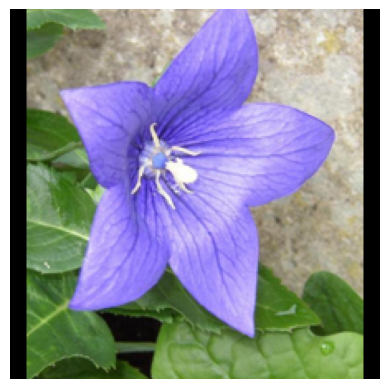

In [17]:
def imshow(image, ax=None, title=None):
    """Displays an image tensor after undoing normalization."""
    
    # Create a new figure and axis if none provided
    if ax is None:
        fig, ax = plt.subplots()
    
    # Convert tensor to numpy and reorder dimensions from (C, H, W) to (H, W, C)
    image = image.transpose((1, 2, 0))
    
    # Undo normalization using the mean and std of ImageNet (if that's the model's source)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    
    # Clip values to the range [0, 1] for correct display
    image = np.clip(image, 0, 1)
    
    # Display the image
    ax.imshow(image)
    
    # Optionally set the title
    if title:
        ax.set_title(title)
    
    # Hide axis labels for clarity
    ax.axis('off')
    
    return ax


imshow(processed_image)

## Class Prediction

Once you can get images in the correct format, it's time to write a function for making predictions with your model. A common practice is to predict the top 5 or so (usually called top-$K$) most probable classes. You'll want to calculate the class probabilities then find the $K$ largest values.

To get the top $K$ largest values in a tensor use [`x.topk(k)`](http://pytorch.org/docs/master/torch.html#torch.topk). This method returns both the highest `k` probabilities and the indices of those probabilities corresponding to the classes. You need to convert from these indices to the actual class labels using `class_to_idx` which hopefully you added to the model or from an `ImageFolder` you used to load the data ([see here](#Save-the-checkpoint)). Make sure to invert the dictionary so you get a mapping from index to class as well.

Again, this method should take a path to an image and a model checkpoint, then return the probabilities and classes.

```python
probs, classes = predict(image_path, model)
print(probs)
print(classes)
> [ 0.01558163  0.01541934  0.01452626  0.01443549  0.01407339]
> ['70', '3', '45', '62', '55']
```

In [27]:
# Path to the image to predict
image_path = './flowers/test/49/image_06202.jpg'

# Converts class names (from json file) into labels based on class indices
def class_to_label(file, class_indices):
    """Maps class indices to human-readable class names."""
    with open(file, 'r') as f:
        class_mapping = json.load(f)
    
    labels = [class_mapping[str(c)] for c in class_indices]
    return labels

# Mapping class indices to class names
idx_mapping = {v: k for k, v in class_to_idx.items()}

# Function to predict the top K classes for a given image
def predict(image_path, model, idx_mapping, topk, device):
    """Predicts the top k classes for a given image."""
    # Process the image and move it to the correct device
    processed_image = torch.from_numpy(process_image(image_path)).unsqueeze(0).to(device).float()

    model.to(device)
    model.eval()

    with torch.no_grad():  # Avoid gradient computation during inference
        log_ps = model(processed_image)
        ps = torch.exp(log_ps)  # Convert log probabilities to actual probabilities

    top_ps, top_idx = ps.topk(topk, dim=1)
    
    probabilities = top_ps.tolist()[0]
    indices = top_idx.tolist()[0]
    
    # Map indices to class names
    classes = [idx_mapping[idx] for idx in indices]
    
    return probabilities, classes

# Function to print the predictions with probabilities and corresponding class labels
def print_predictions(probabilities, classes, image, category_names=None):
    """Prints the predicted class labels and probabilities."""
    print(f"Image: {image}")
    
    if category_names:
        labels = class_to_label(category_names, classes)
        for i, (prob, label, cls) in enumerate(zip(probabilities, labels, classes), 1):
            print(f"{i}) {prob*100:.2f}% {label.title()} | Class No. {cls}")
    else:
        for i, (prob, cls) in enumerate(zip(probabilities, classes), 1):
            print(f"{i}) {prob*100:.2f}% Class No. {cls}")
    
    print("")

# Example usage
probabilities, classes = predict(image_path, model, idx_mapping, topk=5, device=device)
print_predictions(probabilities, classes, image_path.split('/')[-1], 'cat_to_name.json')

C:\Users\joshg\AppData\Local\Temp\ipykernel_12092\2065334108.py:34: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  processed_image_np = np.array(tensor_image)


Image: image_06202.jpg
1) 47.41% Oxeye Daisy | Class No. 49
2) 32.56% Barbeton Daisy | Class No. 41
3) 12.03% Purple Coneflower | Class No. 17
4) 3.93% Japanese Anemone | Class No. 62
5) 3.90% Sunflower | Class No. 54



## Sanity Checking

Now that you can use a trained model for predictions, check to make sure it makes sense. Even if the testing accuracy is high, it's always good to check that there aren't obvious bugs. Use `matplotlib` to plot the probabilities for the top 5 classes as a bar graph, along with the input image. It should look like this:

<img src='assets/inference_example.png' width=300px>

You can convert from the class integer encoding to actual flower names with the `cat_to_name.json` file (should have been loaded earlier in the notebook). To show a PyTorch tensor as an image, use the `imshow` function defined above.

C:\Users\joshg\AppData\Local\Temp\ipykernel_12092\2065334108.py:34: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  processed_image_np = np.array(tensor_image)


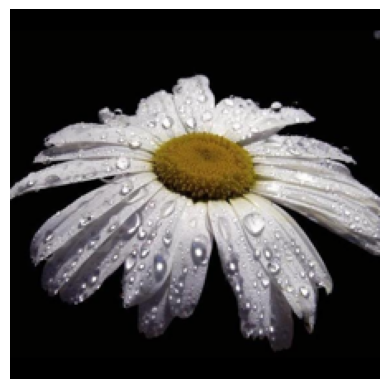

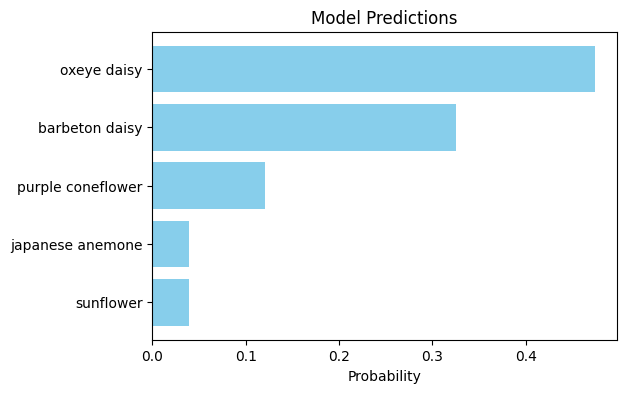

In [28]:
# Display the image using imshow function
image = process_image(image_path)
imshow(image)

# Create a figure for the bar chart
plt.figure(figsize=(6, 4))  # Set the figure size to make the plot more readable

# Create a horizontal bar chart for probabilities
plt.barh(class_to_label('cat_to_name.json', classes), width=probabilities, color='skyblue')

# Set the title of the chart
plt.title('Model Predictions')

# Invert the y-axis to display the highest probability at the top
plt.gca().invert_yaxis()

# Display the chart
plt.xlabel('Probability')
plt.show()